# Customer Sales Analysis — Intern Training Notebook

## Role: Junior Data Analyst Intern

This notebook is designed to teach you **how a real data analyst approaches a business dataset**, not just how to make graphs.

### Your workflow

**Business question → Data → Cleaning → Exploration → Analysis → Visualization → Insight → Recommendation**

You should run each section, inspect the output, and try to explain the result **before reading the conclusion**.

### Dataset

This project uses the Superstore-style customer sales dataset you have been working with.

Expected file:

```text
superstore.xls
```

Keep `superstore.xls` in the same folder as this notebook, or change the file path in the loading cell.

---

## Important analyst rule

A chart tells you **what happened**.

An analyst must investigate:

1. What happened?
2. How large is the difference?
3. Why might it be happening?
4. Does it matter to the business?
5. What should we investigate or do next?

Do not confuse **observation** with **business insight**.

## Project Objectives

By the end of this notebook, you should be able to:

- Inspect a real dataset
- Understand columns and data types
- Check missing values and duplicates
- Clean common data problems
- Calculate business KPIs
- Analyze sales, profit, customers, products, regions and segments
- Visualize trends and comparisons
- Automatically screen numerical relationships with correlation
- Investigate discount vs profit
- Identify loss-making products
- Turn findings into business recommendations
- Write an executive-style conclusion

### Core business questions

**Revenue**
- Which category generates the most sales?
- Which region generates the most sales?
- Which customer segment generates the most sales?
- Which products are top sellers?
- How are sales changing over time?
- Are there seasonal patterns?

**Profitability**
- Which category is most profitable?
- Which region is most profitable?
- Which products generate losses?
- Does discount appear to be associated with profit?

**Operations**
- Which shipping mode is most common?
- How long does shipping take?
- Does shipping cost relate to profit?

In [ ]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot style
sns.set_theme(style="whitegrid")

# 1. Load the Data

First, load the dataset.

Do not start analysis before confirming that the data loaded correctly.

In [ ]:
# The supplied file is CSV-formatted text with an .xls extension.
FILE_PATH = "superstore.xls"

df = pd.read_csv(FILE_PATH)

# Normalize the source column names so the rest of the notebook uses readable names.
df = df.rename(columns={
    "Customer.ID": "Customer_Id",
    "Customer.Name": "Customer_Name",
    "Order.Date": "Order_Date",
    "Order.ID": "Order_Id",
    "Order.Priority": "Order_Priority",
    "Product.ID": "Product_Id",
    "Product.Name": "Product_Name",
    "Row.ID": "Row_Id",
    "Ship.Date": "Shipping_Date",
    "Ship.Mode": "Shipping_Mode",
    "Shipping.Cost": "Shipping_Cost",
    "Sub.Category": "Sub_Category",
    "Market2": "Sold_to",
    "weeknum": "weekNum",
    "记录数": "Record_Count"
})

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

### Intern task

Before moving forward, answer:

- What does one row represent?
- How many rows are there?
- What kind of business information is available?
- Which columns look useful for revenue analysis?
- Which columns look useful for profitability analysis?

Do not worry if you cannot answer everything yet. We will investigate.

# 2. Understand the Dataset

A professional analyst does not immediately make charts.

First understand the structure of the data.

In [ ]:
print("Rows and columns:", df.shape)

In [ ]:
df.info()

In [ ]:
# Numerical summary
df.describe()

In [ ]:
# Number of unique values in every column
df.nunique().sort_values(ascending=False)

### Why are we doing this?

`shape` tells us the size.

`info()` tells us:
- column names
- missing values
- data types

`describe()` gives numerical statistics.

`nunique()` helps identify:
- identifiers
- categorical variables
- columns with very few unique values

This prevents us from treating every column the same way.

# 3. Data Quality Checks

Before trusting the analysis, check:

1. Missing values
2. Duplicate rows
3. Incorrect data types
4. Duplicate/redundant columns
5. Columns that do not contribute to business analysis

In [ ]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

In [ ]:
# Duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

## Date columns

Your dataset may contain both `Order_Date` and `Order_date`, depending on which version of the CSV you are using.

We will check for both.

In [ ]:
date_columns = [col for col in ["Order_Date", "Order_date", "Shipping_Date"] if col in df.columns]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("Date columns found:", date_columns)

In [ ]:
# If both Order_Date and Order_date exist, check whether they contain the same dates.

if "Order_Date" in df.columns and "Order_date" in df.columns:
    print("Are Order_Date and Order_date identical?",
          df["Order_Date"].equals(df["Order_date"]))

In [ ]:
# Remove the redundant lowercase date column if it exists and is identical.
if (
    "Order_Date" in df.columns
    and "Order_date" in df.columns
    and df["Order_Date"].equals(df["Order_date"])
):
    df.drop(columns=["Order_date"], inplace=True)

# Record_Count is constant in this dataset and does not add analytical information.
if "Record_Count" in df.columns and df["Record_Count"].nunique() == 1:
    df.drop(columns=["Record_Count"], inplace=True)

df.info()

### Analyst note

Do not delete a column simply because it looks unimportant.

First investigate it.

For example, `Record_Count` contains only `1` in your dataset, so it carries no variation and does not help explain business performance.

Likewise, `Row_Id` is an identifier rather than a business metric.

**Cleaning should be evidence-based.**

# 4. Explore Categorical Variables

Categorical columns answer questions such as:

- Which categories exist?
- Which regions exist?
- Which segments exist?
- Which shipping modes are used?
- Which countries are represented?

Start with `value_counts()`.

In [ ]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    print(f"\n{'='*15} {col} {'='*15}")
    print(df[col].value_counts().head(15))

### Intern thinking

A frequency table tells you **how often something occurs**.

But frequency is not the same as revenue.

For example:

> Office Supplies may have more records than Technology.

That does **not** automatically mean Office Supplies generates more sales.

We therefore need to distinguish:

**Number of transactions** vs **Sales** vs **Profit**.

# 5. Create Useful Time Features

We can extract useful information from `Order_Date`.

We will create:

- Year
- Month
- Month name
- Shipping days

In [ ]:
if "Order_Date" in df.columns:
    df["Year"] = df["Order_Date"].dt.year
    df["Month"] = df["Order_Date"].dt.month
    df["Month_Name"] = df["Order_Date"].dt.month_name()

if "Order_Date" in df.columns and "Shipping_Date" in df.columns:
    df["Shipping_Days"] = (df["Shipping_Date"] - df["Order_Date"]).dt.days

df.head()

# 6. Business KPIs

Before making many visualizations, calculate the high-level numbers a manager would care about.

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
unique_orders = df["Order_Id"].nunique() if "Order_Id" in df.columns else np.nan
unique_customers = df["Customer_Id"].nunique() if "Customer_Id" in df.columns else np.nan

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales:       ${total_sales:,.2f}")
print(f"Total Profit:      ${total_profit:,.2f}")
print(f"Total Quantity:    {total_quantity:,.0f}")
print(f"Unique Orders:     {unique_orders:,.0f}")
print(f"Unique Customers:  {unique_customers:,.0f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

### Why KPIs matter

A company normally wants a quick answer to:

- How much revenue did we generate?
- How much profit did we make?
- How many orders/customers did we have?
- What is our profit margin?

These numbers provide the context for every later chart.

# 7. Visualization 1 — Total Sales by Category

### Business question

> Which product category generates the most revenue?

### Analyst workflow

**Group → Aggregate → Sort → Visualize → Interpret**

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

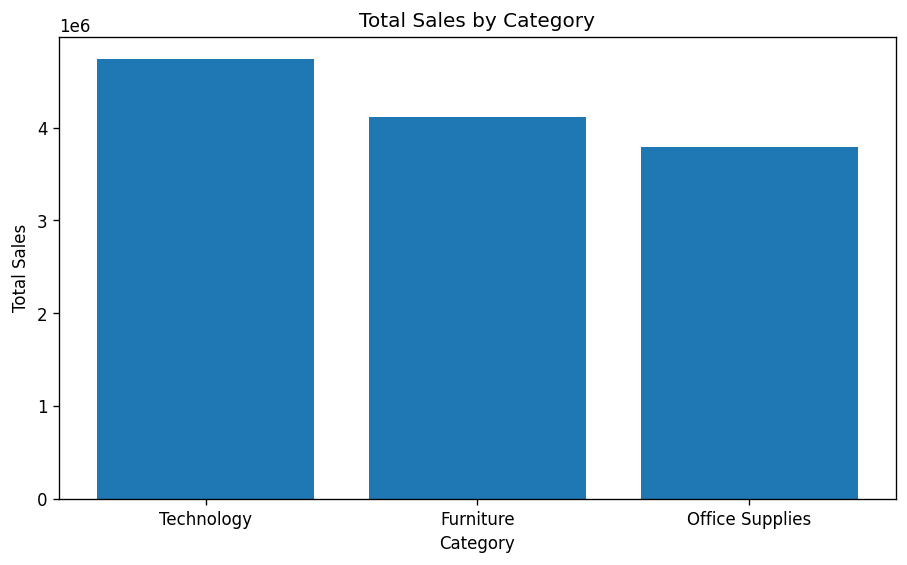

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### How to interpret this chart

Do not simply write:

> Technology is highest.

Use this framework:

**Observation:** Which category is highest?

**Comparison:** How much higher/lower is it than the others?

**Meaning:** What does that indicate about customer demand?

**Business implication:** Should the company investigate inventory, marketing, pricing or product mix?

**Next question:** Is the highest-sales category also the highest-profit category?

### Important

**Sales ≠ Profit.**

Never recommend investing more in a category using sales alone.

# 8. Visualization 2 — Total Sales by Region

### Business question

> Which geographical region generates the most revenue?

In [ ]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

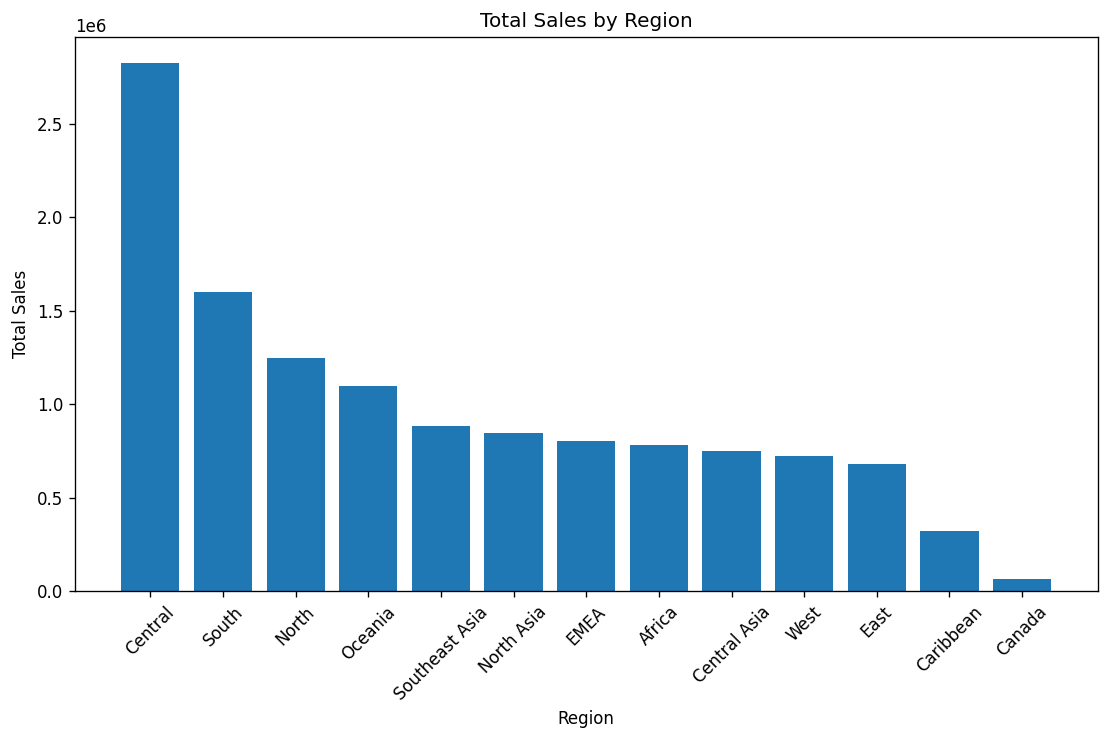

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analyst questions

If one region is far ahead of the others, do not stop there.

Ask:

- Does that region also have the most orders?
- Does it have the most customers?
- Which categories drive its sales?
- Is it also highly profitable?
- Can successful strategies from that region be replicated elsewhere?

This is called **drill-down analysis**.

# 9. Visualization 3 — Sales Trend by Year

### Business question

> Is the company's revenue growing or declining over time?

In [ ]:
yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .sort_index()
)

yearly_sales

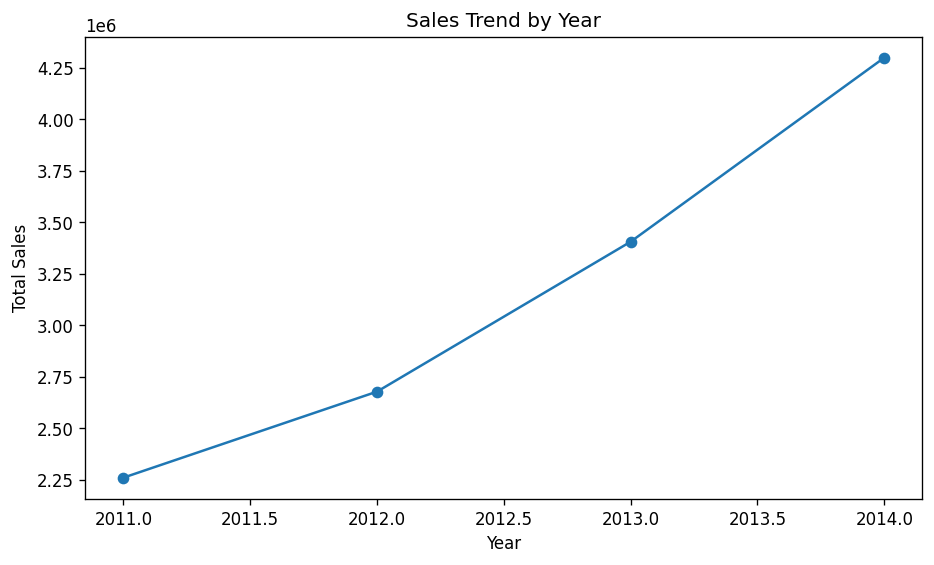

In [ ]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker="o"
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [ ]:
# Year-over-year growth

yearly_growth = yearly_sales.pct_change() * 100

growth_table = pd.DataFrame({
    "Sales": yearly_sales,
    "YoY_Growth_%": yearly_growth
})

growth_table

### Why calculate growth?

A line chart shows direction.

Growth percentages show **how quickly the business changed**.

For example:

> Sales increased.

is weaker than:

> Sales increased by approximately X% compared with the previous year.

That is more useful to management.

# 10. Visualization 4 — Monthly Sales Pattern

### Business question

> Are there months where demand is consistently higher or lower?

We first calculate total sales by calendar month across the entire dataset.

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_index()
)

monthly_sales

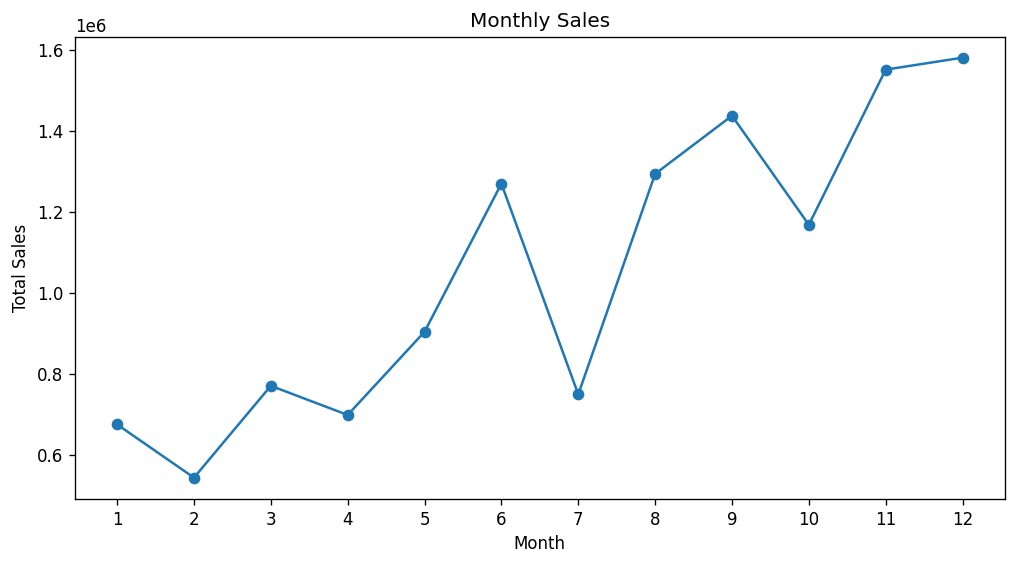

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Important analyst caution

This chart combines all years.

Therefore, a conclusion such as:

> "December is always the best month"

would be too strong.

A safer statement is:

> "Across the full dataset, December has the highest total sales."

To test whether this pattern is consistent, compare **Year × Month** next.

In [ ]:
year_month_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

year_month_sales.head(12)

### Better seasonal analysis

A real analyst would compare the same months across years before recommending seasonal inventory or marketing changes.

# 11. Visualization 5 — Top 10 Products by Sales

### Business question

> Which individual products contribute the most revenue?

In [ ]:
top_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

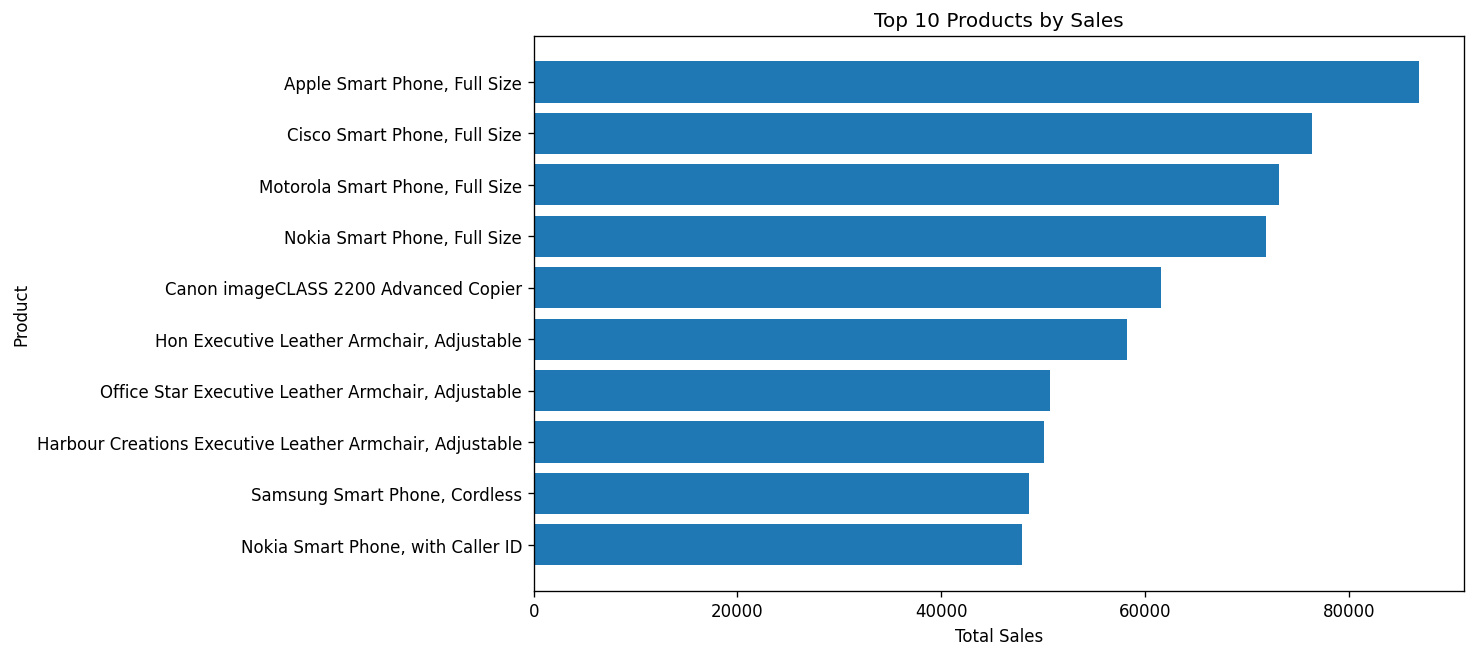

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business interpretation

Top-selling products may deserve:

- inventory monitoring
- availability checks
- marketing attention
- pricing analysis

But again:

**Top seller ≠ most profitable product.**

The next step is to compare these products with profit.

# 12. Visualization 6 — Sales by Customer Segment

### Business question

> Which customer segment generates the most revenue?

In [ ]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

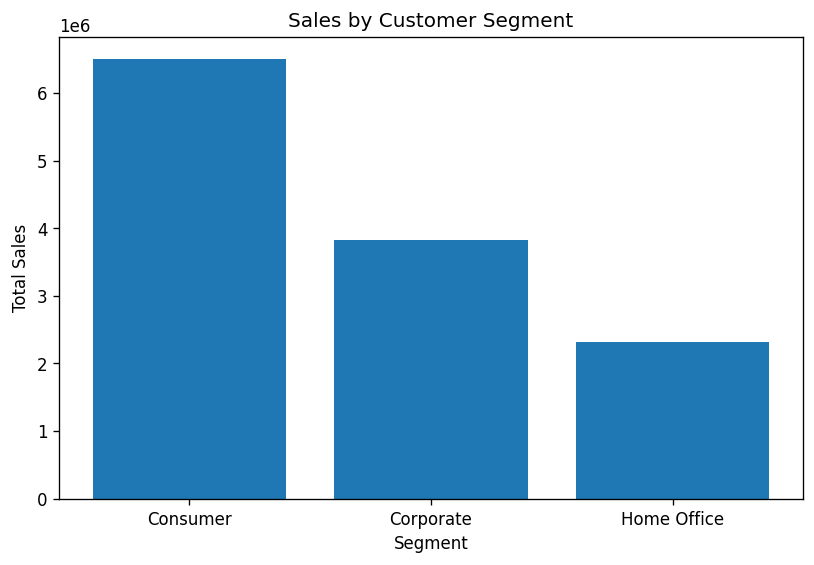

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Drill-down questions

If Consumer is the largest segment, ask:

- Does Consumer also have the highest profit?
- Does Consumer have the most customers?
- Is its average order value higher?
- Which products does Consumer purchase?

A strong analyst moves from **summary → explanation**.

# 13. Visualization 7 — Profit by Category

This is one of the most important charts because revenue alone can be misleading.

### Business question

> Which category actually contributes the most profit?

In [ ]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

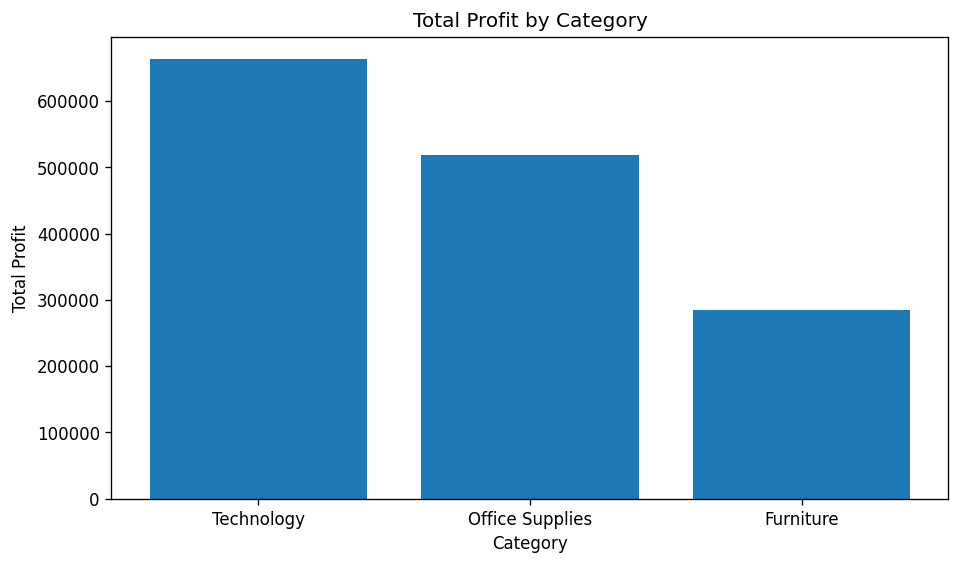

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

### Key analyst lesson

Now compare:

**Sales by Category**

with:

**Profit by Category**

A category can have:

- high sales + high profit → attractive
- high sales + low profit → needs investigation
- low sales + high profit margin → potentially valuable
- low sales + negative profit → needs investigation

This is why analysts never make major recommendations from one chart alone.

# 14. Visualization 8 — Profit by Region

### Business question

> Which regions are actually profitable?

In [ ]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit

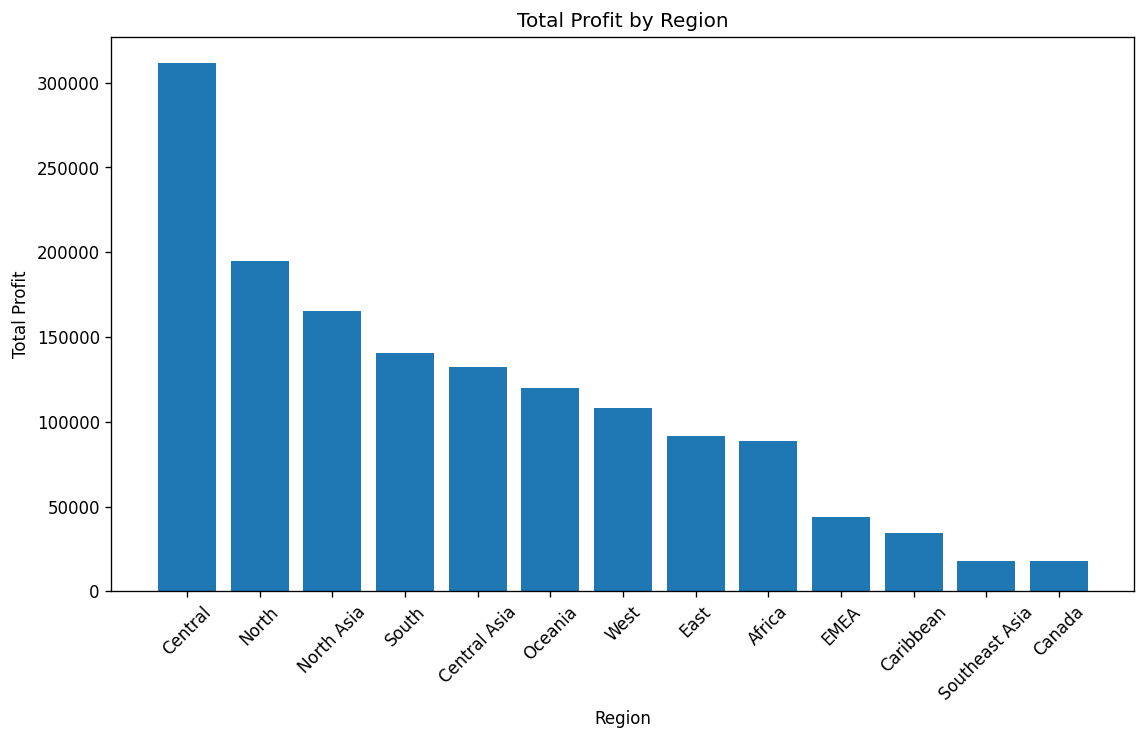

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Important comparison

Your highest-sales region is not automatically your highest-profit region.

If the rankings differ, that is an important business finding.

Possible reasons could include:

- product mix
- discount levels
- shipping costs
- pricing
- customer mix

Those become your next investigation questions.

# 15. Visualization 9 — Discount vs Profit

### Business question

> Is there an observable relationship between discount and profit?

A scatter plot lets us inspect individual observations.

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.3
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### What to look for

Look for:

- direction of the relationship
- clustering
- extreme values
- whether high discounts contain more losses

From your earlier chart, higher discounts appear to contain more negative-profit observations.

However:

**Do not say that discount causes losses based on this chart alone.**

A safer conclusion is:

> Higher discount levels appear to be associated with lower profitability and more loss-making transactions.

We can test the pattern more systematically.

In [ ]:
# Average, median and number of transactions at each discount level

discount_analysis = (
    df.groupby("Discount")["Profit"]
      .agg(["mean", "median", "count"])
      .sort_index()
)

discount_analysis

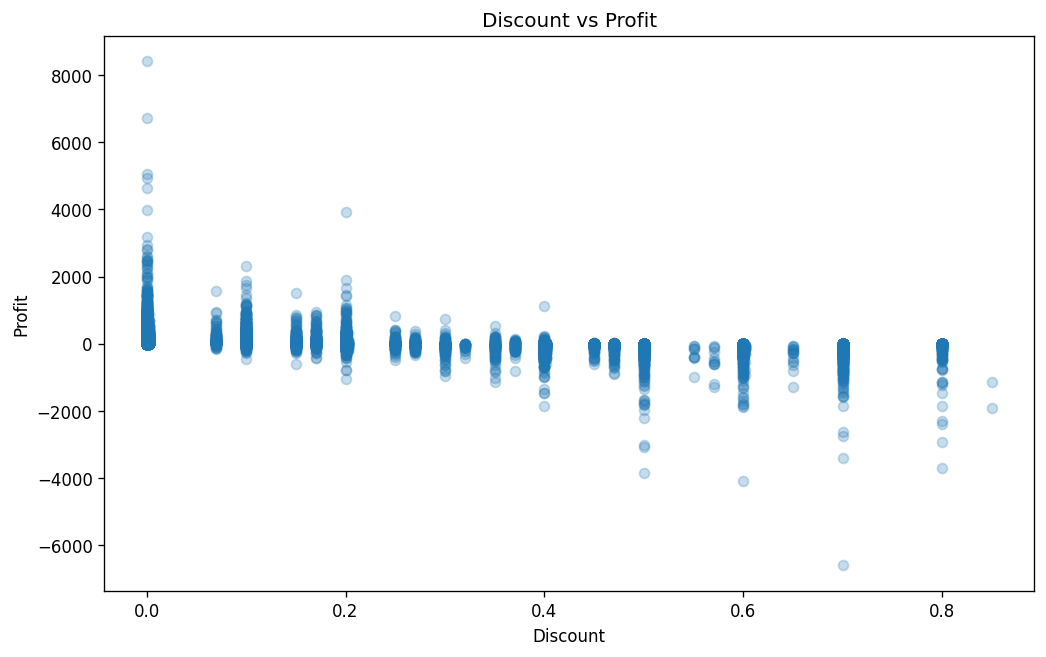

In [ ]:
# Percentage of transactions that are loss-making at each discount level

df["Is_Loss"] = df["Profit"] < 0

loss_rate_by_discount = (
    df.groupby("Discount")["Is_Loss"]
      .mean()
      .mul(100)
      .sort_index()
)

loss_rate_by_discount

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=loss_rate_by_discount.index,
    y=loss_rate_by_discount.values,
    marker="o"
)

plt.title("Loss-Making Transactions by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Loss-Making Transactions (%)")
plt.tight_layout()
plt.show()

### Business interpretation

This is stronger than the original scatter plot because we are now asking:

> "At each discount level, what percentage of transactions lose money?"

That is a business metric.

Management can use this to investigate whether high discounts are financially justified by additional sales volume.

# 16. Automatic Numerical Relationship Discovery

### Your earlier question

> "If the dataset is large, do I have to manually find every correlation?"

**No.**

For numerical variables, use a correlation matrix to screen many relationships at once.

In [ ]:
numeric_columns = [
    col for col in [
        "Discount",
        "Profit",
        "Quantity",
        "Sales",
        "Shipping_Cost",
        "Shipping_Days"
    ]
    if col in df.columns
]

correlation = df[numeric_columns].corr()

correlation

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Business Variables")
plt.tight_layout()
plt.show()

## How to use a correlation matrix

Think of it as a **screening tool**.

### Rough interpretation

- close to `+1` → strong positive linear relationship
- close to `-1` → strong negative linear relationship
- close to `0` → weak linear relationship

But correlation is **not proof of causation**.

### Example

If:

```text
Discount ↔ Profit = -0.40
```

you can say:

> Discount and profit have a negative linear association.

You cannot automatically say:

> Discount causes profit to decrease.

There may be other variables involved.

### The professional workflow

**Correlation matrix → identify interesting relationship → investigate with charts/statistics → understand business context → make recommendation**

# 17. Find the Strongest Correlations Automatically

Instead of manually scanning a large matrix, we can extract the unique pairs.

This becomes especially useful when you have many numerical columns.

In [ ]:
corr_pairs = (
    correlation.where(
        np.triu(np.ones(correlation.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_pairs

### Why this is useful

Imagine a dataset has 20 numerical variables.

The correlation matrix is already useful, but a sorted list lets you quickly identify the strongest relationships.

Then you investigate only the relationships that matter.

This is an example of **automated discovery followed by human analysis**.

# 18. Profitability Analysis — Loss-Making Products

### Business question

> Which products are generating negative total profit?

This is often more actionable than simply finding the top sellers.

In [ ]:
product_profit = (
    df.groupby("Product_Name")["Profit"]
      .sum()
      .sort_values()
)

loss_making_products = product_profit[product_profit < 0]

loss_making_products.head(15)

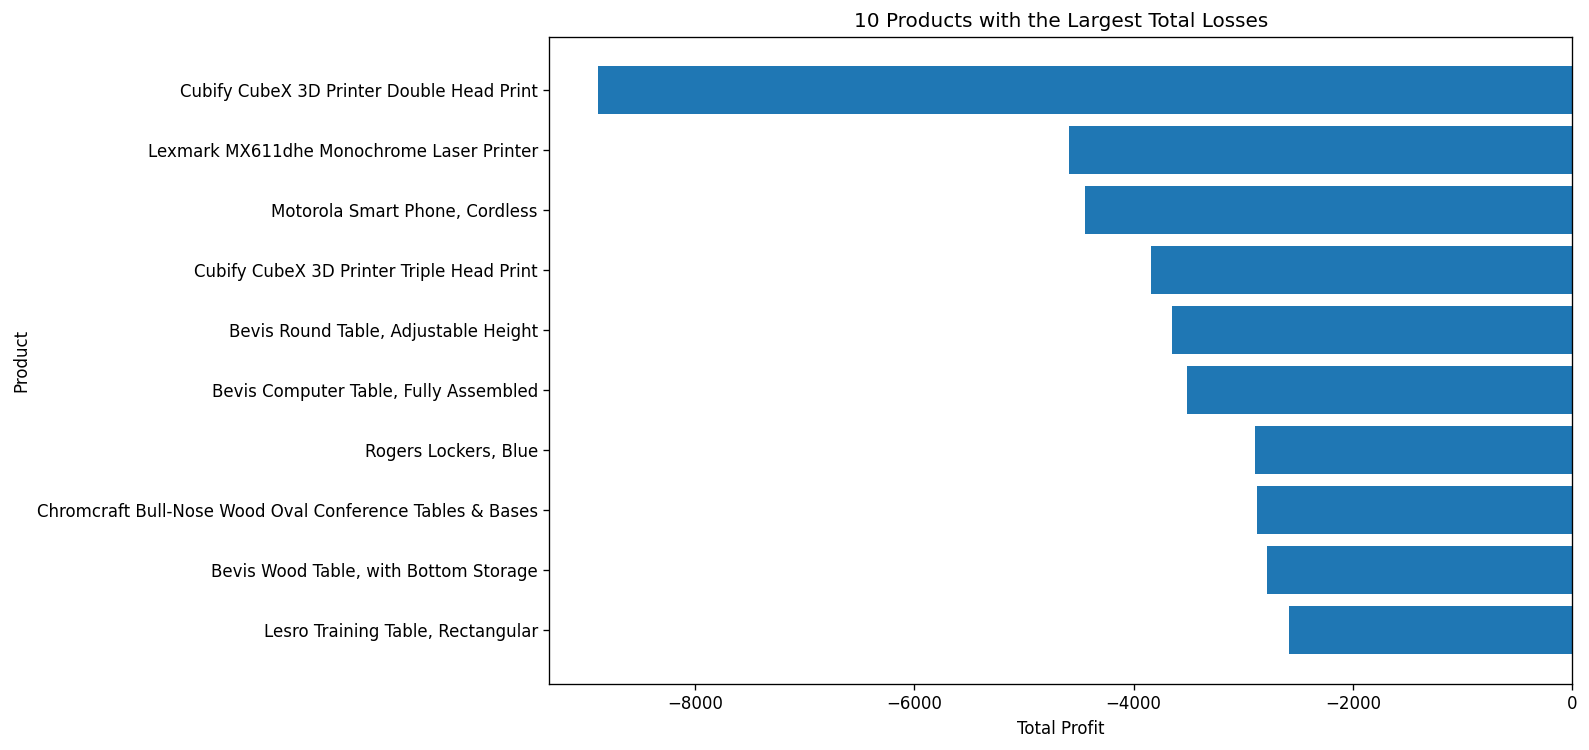

In [ ]:
plt.figure(figsize=(11, 7))

sns.barplot(
    x=loss_making_products.head(10).values,
    y=loss_making_products.head(10).index
)

plt.title("10 Products with the Largest Total Losses")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business questions

For loss-making products, investigate:

- Is the discount unusually high?
- Is shipping cost high?
- Is the product price too low?
- Is the product frequently returned? (if returns data exists)
- Is demand high enough to justify the product?
- Is the problem specific to a region or customer segment?

Do not immediately recommend removing a product. Investigate first.

# 19. Sales vs Profit — A Better Product View

A useful business analysis is to compare product revenue and profitability.

We will calculate:

- total sales
- total profit
- quantity
- profit margin

In [ ]:
product_performance = (
    df.groupby("Product_Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
)

product_performance["Profit_Margin_%"] = (
    product_performance["Profit"] /
    product_performance["Sales"] * 100
)

product_performance.sort_values("Sales", ascending=False).head(10)

### Why this is better

Now you can distinguish:

**High-sales products**

from

**High-profit products**

and

**High-margin products**.

These are different business concepts.

# 20. Shipping Analysis

Your dataset also contains shipping information.

### Business questions

- Which shipping mode is most common?
- What is the average shipping time?
- Does shipping cost vary by mode?

In [ ]:
shipping_summary = (
    df.groupby("Shipping_Mode")
      .agg(
          Orders=("Order_Id", "nunique"),
          Avg_Shipping_Days=("Shipping_Days", "mean"),
          Avg_Shipping_Cost=("Shipping_Cost", "mean"),
          Total_Shipping_Cost=("Shipping_Cost", "sum")
      )
      .sort_values("Orders", ascending=False)
)

shipping_summary

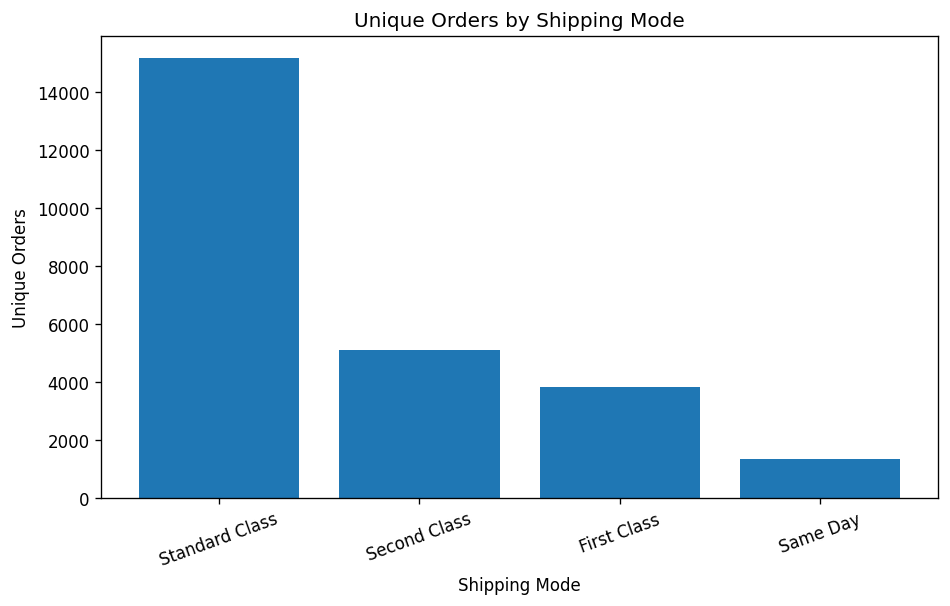

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=shipping_summary.index,
    y=shipping_summary["Orders"]
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Analyst thinking

The most-used shipping mode is not necessarily the best one.

You could investigate:

- speed
- cost
- customer segment
- region
- profitability

Again:

**frequency ≠ performance**.

# 21. Sales and Profit by Segment

We previously analyzed sales by segment.

Now compare sales and profit together.

In [ ]:
segment_performance = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_Id", "nunique"),
          Customers=("Customer_Id", "nunique")
      )
)

segment_performance["Profit_Margin_%"] = (
    segment_performance["Profit"] /
    segment_performance["Sales"] * 100
)

segment_performance.sort_values("Sales", ascending=False)

### This table is more powerful than a single chart.

For each segment, you can compare:

**Sales + Profit + Orders + Customers + Profit Margin**

This helps answer questions such as:

> Is the largest segment also the most profitable?

> Does a segment generate high sales because it has many orders, or because each order is valuable?

# 22. Average Order Value

Revenue alone can be misleading when the number of orders differs.

A useful KPI is:

**Average Order Value = Total Sales / Number of Orders**

In [ ]:
if "Order_Id" in df.columns:
    aov = (
        df.groupby("Segment")
          .agg(
              Sales=("Sales", "sum"),
              Orders=("Order_Id", "nunique")
          )
    )

    aov["Average_Order_Value"] = aov["Sales"] / aov["Orders"]

    aov.sort_values("Average_Order_Value", ascending=False)

### Why this matters

Suppose:

- Segment A has 10,000 orders and $1M sales
- Segment B has 5,000 orders and $900K sales

Segment A has more sales, but Segment B has a much higher average order value.

This gives management a different perspective.

# 23. Customer Analysis

Now move from products to customers.

### Business question

> Which customers generate the most revenue?

In [ ]:
customer_performance = (
    df.groupby(["Customer_Id", "Customer_Name"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_Id", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

customer_performance.head(10)

### Possible business use

High-value customers may deserve:

- retention programs
- account management
- personalized offers
- service prioritization

But again, high revenue does not necessarily mean high profitability.

# 24. Build a Management Summary Table

A real analyst often creates a compact summary instead of making management inspect every chart.

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Unique Orders",
        "Unique Customers",
        "Top Sales Category",
        "Top Sales Region",
        "Top Sales Segment",
        "Top Sales Product"
    ],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        f"{profit_margin:.2f}%",
        f"{unique_orders:,.0f}",
        f"{unique_customers:,.0f}",
        category_sales.index[0],
        region_sales.index[0],
        segment_sales.index[0],
        top_products.index[0]
    ]
})

summary

# Dataset-Specific Findings From Your Uploaded Data

I calculated these values from the actual `superstore.xls` file you supplied:

- **51,290 rows**
- **27 source columns**
- **Total Sales:** $12,642,905
- **Total Profit:** $1,467,457
- **Overall Profit Margin:** 11.61%
- **Unique Orders:** 25,035
- **Unique Customers:** 4,873

### Main findings

1. **Technology** leads category sales at $4,744,691 and also leads category profit at $663,779.
2. **Central** leads both regional sales ($2,822,399) and regional profit ($311,404).
3. **Consumer** is the largest sales segment at $6,508,141.
4. Sales increase from $2,259,511 in 2011 to $4,300,041 in 2014.
5. The discount analysis shows a negative association between discount and profit; higher discount levels contain many more loss-making transactions.
6. Product-level analysis shows why **Sales, Profit and Margin must be considered together**.

### Important caution

These are descriptive findings from this dataset. They do not prove causation. In particular, correlation and scatter plots show association, not cause-and-effect.

# 25. Final Business Insight Framework

For every important finding, write it using this structure:

### 1. Observation
What does the data show?

### 2. Evidence
What number/chart supports it?

### 3. Interpretation
What could it mean?

### 4. Business impact
Why should management care?

### 5. Recommendation
What should be investigated or considered?

### 6. Limitation
What can we NOT conclude from this analysis?

---

## Example

### Weak

> Technology has the highest sales.

### Better

> Technology generates the highest sales among the three categories.

### Analyst-level

> Technology is the largest revenue-generating category. This indicates strong demand, but sales alone do not establish that it is the best category financially. Profit, margin, discount levels and product-level performance should be examined before making investment or inventory decisions.

### Why the last version is better

It:

- states the finding
- avoids overclaiming
- connects the finding to a business decision
- identifies the next analysis

# 26. Your Executive Summary Template

After running the notebook, replace the placeholders below with your actual results.

## Executive Summary

### Revenue
- Total sales: **$...**
- Highest-revenue category: **...**
- Highest-revenue region: **...**
- Highest-revenue customer segment: **...**

### Growth
- Sales trend from **... to ...**: **...**
- Strongest/weakest year-over-year growth: **...**

### Profitability
- Total profit: **$...**
- Overall profit margin: **...%**
- Highest-profit category: **...**
- Lowest-profit category: **...**

### Customers and products
- Top-selling product: **...**
- Highest-revenue segment: **...**
- Highest-value customer: **...**

### Discount
- Discount-profit relationship: **...**
- Loss-making transaction pattern: **...**

### Business recommendations
1. **...**
2. **...**
3. **...**

### Further investigation
1. **...**
2. **...**
3. **...**

# 27. Intern Challenge — Do This Yourself

Now pretend that your manager gives you only this request:

> **"Analyze our sales data and tell me what management should know."**

Do not look at the earlier conclusions.

Use the notebook to answer:

### Revenue
1. What is our total sales?
2. Which category leads sales?
3. Which region leads sales?
4. Which segment leads sales?

### Growth
5. Are sales increasing over time?
6. Are there seasonal patterns?

### Profitability
7. Which category leads profit?
8. Which region leads profit?
9. Which products are loss-making?
10. Does discount appear related to profit?

### Customers/products
11. Which products are top sellers?
12. Which customers generate the most revenue?
13. Is the highest-sales segment also the highest-profit segment?

### Operations
14. Which shipping mode is most used?
15. How long does shipping take?

### Final task

Write **5 business insights** and **3 recommendations**.

For each insight, use:

**Observation → Evidence → Meaning → Business impact → Recommendation**

# 28. What You Should Learn From This Project

You are not trying to memorize every Pandas or Seaborn command.

You are learning a reusable process:

```text
1. Understand the business problem
        ↓
2. Inspect the dataset
        ↓
3. Clean the data
        ↓
4. Identify variable types
        ↓
5. Calculate KPIs
        ↓
6. Explore individual variables
        ↓
7. Compare groups
        ↓
8. Analyze trends
        ↓
9. Find relationships/correlations
        ↓
10. Drill down into interesting findings
        ↓
11. Turn findings into business insights
        ↓
12. Make evidence-based recommendations
```

### Reuse this workflow for your next projects

For Netflix:

```text
Content → Countries → Genres → Years → Movies vs TV → Trends
```

For IPL:

```text
Teams → Seasons → Players → Runs → Wickets → Venues → Trends
```

The **dataset changes**.

The **analytical thinking stays the same**.

# 29. Final Reminder

A good data analyst does not ask:

> "Which chart should I make?"

A good data analyst asks:

> **"What decision does the business need to make, and what evidence can the data provide?"**

Use charts and statistics as tools to answer that question.

**Do not blindly trust a correlation.**

**Do not confuse sales with profit.**

**Do not claim causation from a visualization.**

**Do not make recommendations without checking the evidence.**

That mindset will be much more valuable to you than memorizing visualization syntax.